In [ ]:
Loading and Preprocessing

In [1]:
# Import necessary libraries
from sklearn.datasets import load_iris
import pandas as pd

# Load the Iris dataset
iris = load_iris()

# Convert dataset into a pandas DataFrame
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add species column (target values)
iris_df['species'] = iris.target

# Display original dataset
print("Original Iris Dataset:")
print(iris_df.head())

# Drop the species column for clustering
iris_clustering_data = iris_df.drop('species', axis=1)

# Display dataset after dropping species column
print("\nDataset after dropping species column:")
print(iris_clustering_data.head())

Original Iris Dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  

Dataset after dropping species column:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4   

In [ ]:
Clustering Algorithm Implementation : KMeans Clustering 

In [ ]:
KMeans clustering is an unsupervised 
machine learning algorithm used to group similar data points into clusters.

Choose the number of clusters K.
Randomly initialize K centroids.
Assign each data point to the nearest centroid.
Recalculate centroids based on assigned points.
Repeat steps 3 and 4 until centroids no longer change significantly.

The algorithm minimizes the distance between data points and their cluster centroids.

Why KMeans is Suitable for the Iris Dataset
The Iris dataset contains flower measurements with natural grouping patterns.
There are three known species of Iris flowers, making it suitable for clustering into 3 groups.
Features such as petal length and petal width help separate the species effectively.
KMeans works well for datasets with compact and well-separated clusters like Iris.

C:\Users\DELL WIN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  Cluster  
0        0        1  
1        0        1  
2        0        1  
3        0        1  
4        0        1  


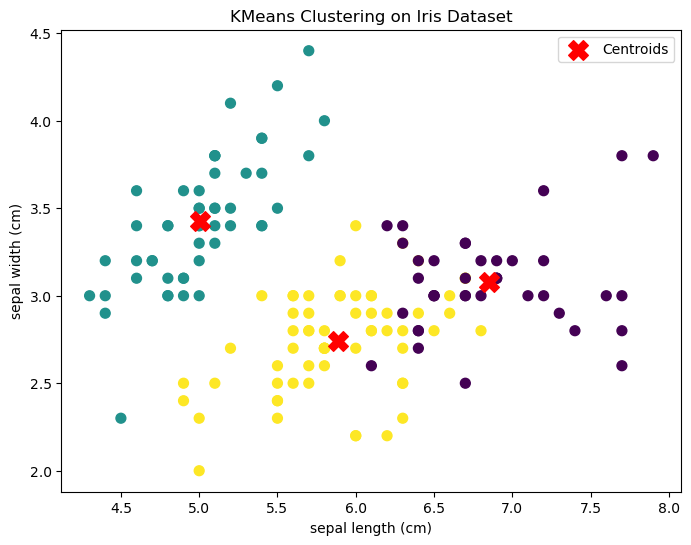

In [2]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import pandas as pd
import matplotlib.pyplot as plt

# Load Iris dataset
iris = load_iris()

# Create DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add species column
df['species'] = iris.target

# Drop species column for clustering
X = df.drop('species', axis=1)

# Apply KMeans Clustering
kmeans = KMeans(n_clusters=3, random_state=42)

# Fit the model and predict clusters
clusters = kmeans.fit_predict(X)

# Add cluster labels to DataFrame
df['Cluster'] = clusters

# Display first few rows
print(df.head())

# Visualize clusters using first two features
plt.figure(figsize=(8, 6))

plt.scatter(
    X.iloc[:, 0], 
    X.iloc[:, 1], 
    c=clusters, 
    cmap='viridis',
    s=50
)

# Plot centroids
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    color='red',
    marker='X',
    s=200,
    label='Centroids'
)

plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title('KMeans Clustering on Iris Dataset')
plt.legend()
plt.show()

In [ ]:
Hierarchical clustering is an unsupervised 
machine learning algorithm used to group similar data points into clusters based on their distance or similarity.

There are two approaches:

Agglomerative (Bottom-Up)
Each data point starts as its own cluster.
Closest clusters are merged step by step.
The process continues until all points belong to one cluster.
Divisive (Top-Down)
Starts with one large cluster.
Splits clusters recursively into smaller clusters.

Hierarchical clustering is commonly visualized using a dendrogram, 
which shows how clusters are merged.

Why Hierarchical Clustering is Suitable for the Iris Dataset

The Iris dataset contains naturally grouped flower measurements.
Hierarchical clustering can reveal relationships between samples without specifying the number of clusters initially.
It works well for small and medium-sized datasets like Iris.
The dendrogram helps visualize cluster formation and similarities among flower samples.

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  Cluster  
0        0        1  
1        0        1  
2        0        1  
3        0        1  
4        0        1  


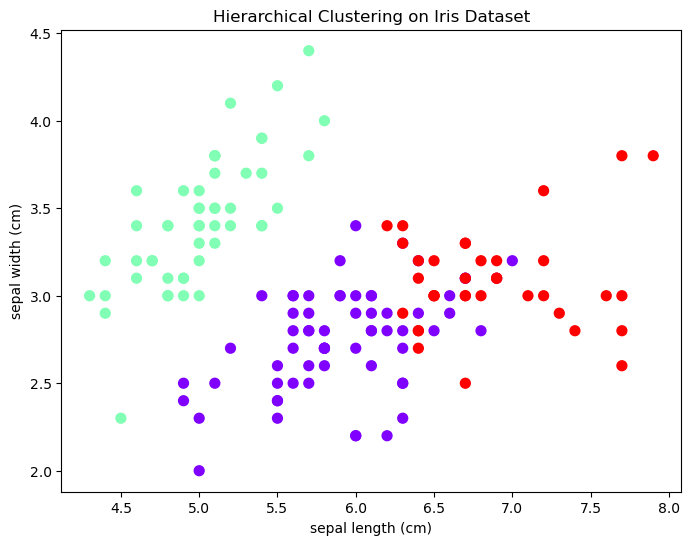

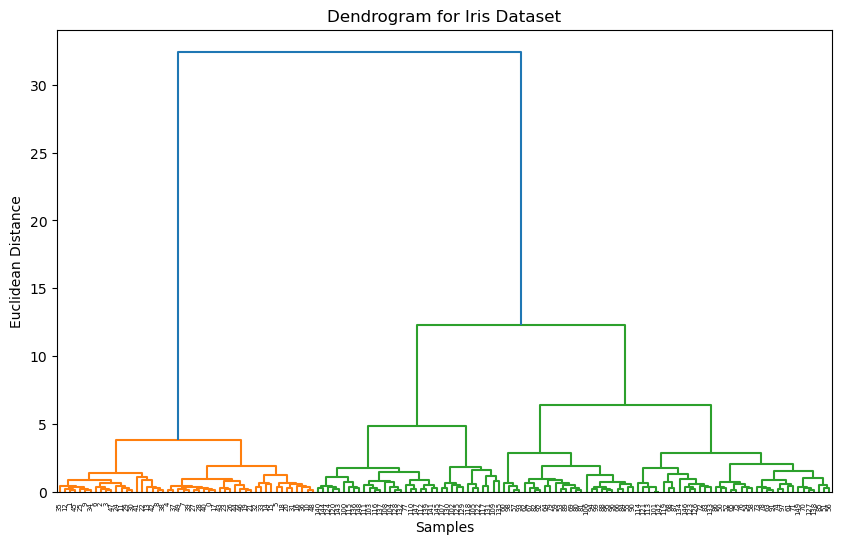

In [4]:
from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# Load Iris dataset
iris = load_iris()

# Create DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add species column
df['species'] = iris.target

# Drop species column for clustering
X = df.drop('species', axis=1)

# Apply Hierarchical Clustering
hc = AgglomerativeClustering(n_clusters=3)

# Predict cluster labels
clusters = hc.fit_predict(X)

# Add cluster labels to DataFrame
df['Cluster'] = clusters

# Display first few rows
print(df.head())


# Visualize Clusters

plt.figure(figsize=(8, 6))

plt.scatter(
    X.iloc[:, 0],
    X.iloc[:, 1],
    c=clusters,
    cmap='rainbow',
    s=50
)

plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title('Hierarchical Clustering on Iris Dataset')

plt.show()


# Create Dendrogram
linked = linkage(X, method='ward')

plt.figure(figsize=(10, 6))

dendrogram(linked)

plt.title('Dendrogram for Iris Dataset')
plt.xlabel('Samples')
plt.ylabel('Euclidean Distance')

plt.show()